In [1]:

import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import time
import pickle

from concurrent.futures import ProcessPoolExecutor, as_completed

import discretize
# from simpeg import dask
from simpeg import (
    maps,
    Data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)
from simpeg.electromagnetics import time_domain as tdem
from simpeg.utils.solver_utils import get_default_solver

from simpeg.meta import MultiprocessingMetaSimulation, MetaSimulation


Solver = get_default_solver()



In [2]:
rho_back = 500
sigma_back = 1./rho_back

rho_target = 20
sigma_target = 1./rho_target

sigma_air = 1e-8

target_dips = np.r_[30] #, 45]
target_z = np.r_[-200, -20]

In [3]:
# rx_locs = np.loadtxt(f"{directory}/rx_locs.txt")
# rx_locs[:, 1] =
tx_height = 30

rx_x = (np.linspace(-500, 500, 101))[::10]

rx_y = (np.linspace(-500, 500, 101))[::20]
# rx_y = np.r_[-80, -40, 0, 40, 80]

rx_z = tx_height

rx_locs = discretize.utils.ndgrid([rx_x, rx_y, rx_z])
rx_x

# rx_times = np.loadtxt(f"{directory}/rx_times.txt")
rx_times = np.logspace(np.log10(2e-5), np.log10(2e-3), 20)

In [5]:
rx_x

array([-500., -400., -300., -200., -100.,    0.,  100.,  200.,  300.,
        400.,  500.])

In [6]:
rx_y

array([-500., -300., -100.,  100.,  300.,  500.])

In [7]:
def diffusion_distance(sigma, t):
    return 1260*np.sqrt(t/sigma)

In [8]:
diffusion_distance(sigma_target, 8e-3)

np.float64(504.0)

In [9]:
diffusion_distance(sigma_back, 8e-3)

np.float64(2520.0)

In [17]:
base_cell_width = 20
domain_extent = 8000

n_base_cells = 2 ** int(
    np.ceil(np.log(domain_extent / base_cell_width) / np.log(2.0))
)  # needs to be powers of 2 for the tree mesh

h = [(base_cell_width, n_base_cells)]
mesh = discretize.TreeMesh([h, h, h], origin="CCC", diagonal_balance=True)

# refine near transmitters and receivers
mesh.refine_points(
    rx_locs, level=-1, padding_cells_by_level=[2, 2],
    finalize=False, diagonal_balance=True
)

# Refine core region of the mesh

bounding_points = np.array([
    [-500, rx_y.min(), target_z.min() - base_cell_width * 4],
    [500, rx_y.max(), 0],
])
mesh.refine_bounding_box(
    bounding_points, level=-1,
    diagonal_balance=True, finalize=False, padding_cells_by_level=[2, 2]
)

mesh.finalize()

In [18]:
mesh

OcTreeMesh: 0.06% filled

Level : Number of cells               Mesh Extent               Cell Widths    
-----------------------           min     ,     max            min   ,   max   
  3   :       448            ---------------------------   --------------------
  4   :       448         x:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  5   :       332         y:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  6   :       840         z:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  7   :      2752      
  8   :      7760      
  9   :      68992     
-----------------------
Total :      81572

In [ ]:
def dipping_target_indices(
    mesh, target_x_center, target_z_center, dip, target_thickness, target_xlim=None, target_ylim=None, target_zlim=None
):
    """
    add a dipping target to the model. For now assumes the target dips in the x-direction
    """
    slope = np.tan(-dip*np.pi/180)
    target_z = target_z_center + target_thickness / 2 * np.r_[-1, 1]

    z_bottom = (mesh.cell_centers[:, 0] - target_x_center) * slope + target_z.min()
    z_top = (mesh.cell_centers[:, 0] - target_x_center) * slope + target_z.max()

    indices = (
        (mesh.cell_centers[:, 2] >= z_bottom) &
        (mesh.cell_centers[:, 2] <= z_top)
    )

    if target_xlim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 0] >= target_xlim.min()) &
            (mesh.cell_centers[:, 0] <= target_xlim.max())
        )
    if target_ylim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 1] >= target_ylim.min()) &
            (mesh.cell_centers[:, 1] <= target_ylim.max())
        )
    if target_zlim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 2] >= target_zlim.min()) &
            (mesh.cell_centers[:, 2] <= target_zlim.max())
        )
    return indices

In [29]:
models = {}

target_x = np.r_[-300, 300]
target_y = np.r_[-200, 200]
target_z_center = -60
target_thickness = 40

# background model
background = np.ones(mesh.n_cells) * sigma_air
background[mesh.cell_centers[:, 2] < 0] = sigma_back
models["background"] = background

for dip in target_dips:
    model = background.copy()
    indices = dipping_target_indices(
        mesh, target_x_center=-100, target_z_center=target_z_center,
        target_thickness=target_thickness, dip=dip,
        target_xlim=target_x,
        target_ylim=target_y,
        target_zlim=np.r_[-200, -20]
    )
    model[indices] = sigma_target
    models[f"target_{dip}"] = model



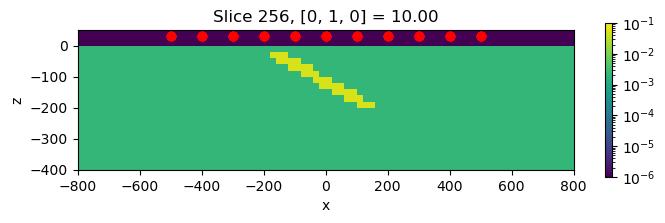

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(8, 2))

plt.colorbar(
    mesh.plot_slice(
        models["target_30"],
        # grid=True,
        normal="y",
        pcolor_opts={"norm":LogNorm(1e-6, 1e-1)},
        ax=ax)[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])

ax.plot(rx_locs[:, 0], rx_locs[:, 2], "ro")
ax.set_aspect(1)

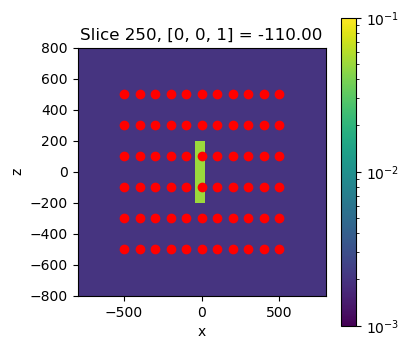

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# mesh_local = mesh_list[-1]

plt.colorbar(
    mesh.plot_slice(
        models["target_30"],
        # grid=True,
        normal="z",
        pcolor_opts={"norm":LogNorm(1e-3, 1e-1)},
        ax=ax,
        ind=250
    )[0],
    ax=ax
)

xlim = 800*np.r_[-1, 1]
ax.set_xlim(xlim)
ax.set_ylim(xlim)

ax.plot(rx_locs[:, 0], rx_locs[:, 1], "ro")
ax.set_aspect(1)


In [32]:
source_list = []

for i in range(rx_locs.shape[0]):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(rx_locs[i, :], rx_times, orientation="z")
    src = tdem.sources.CircularLoop(
        receiver_list=[rx], location=rx_locs[i, :], orientation="z", radius=10,
        waveform=tdem.sources.StepOffWaveform()
    )
    source_list.append(src)

survey = tdem.Survey(source_list)

In [33]:
# set up local meshes
global_mesh = mesh
active_cells_map = maps.InjectActiveCells(global_mesh, global_mesh.cell_centers[:, 2]<0, value_inactive=np.log(1e-8))

refine_depth = 300
# def get_local_mesh(src):
mesh_list = []
x1 = np.mean(rx_locs[:, 0]) - (np.sum(global_mesh.h[0]) / 2)
x2 = np.mean(rx_locs[:, 1]) - (np.sum(global_mesh.h[1]) / 2)
x3 = np.mean(rx_locs[:, 2]) - (np.sum(global_mesh.h[2]) / 2)

for src in survey.source_list:
# src = survey.source_list[0]
    mesh_local = discretize.TreeMesh(global_mesh.h, origin=global_mesh.origin, diagonal_balance=True)
    refine_points = discretize.utils.ndgrid(
        np.r_[src.location[0]],
        np.r_[src.location[1]],
        np.linspace(-refine_depth, src.location[2], 40)
    )
    mesh_local.refine_points(
        refine_points,
        level=-1,
        padding_cells_by_level=[2, 2, 2],
        finalize=True,
        diagonal_balance=True
    )
    mesh_list.append(mesh_local)

    mesh_local.x0

In [34]:
mesh_local

OcTreeMesh,0.00% filled
Level,Number of cells
2,28
3,252
4,252
5,243
6,268
7,625
8,789
9,792
Total,3249


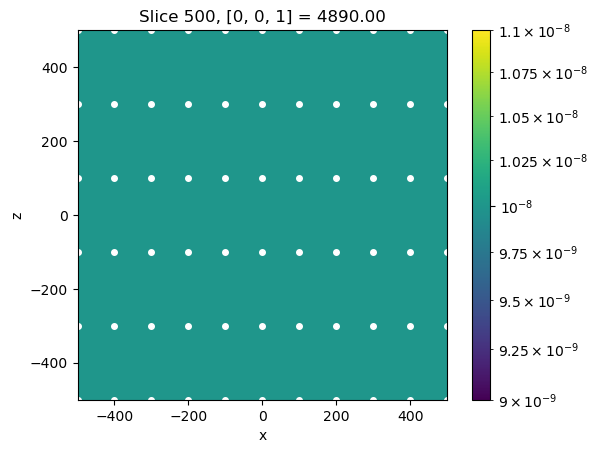

In [35]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        models["target_30"], ax=ax, pcolor_opts={"norm":LogNorm()},
        normal="Z", ind=500
    )[0],
    ax=ax
)

ax.set_xlim(500*np.r_[-1, 1])
ax.set_ylim(500*np.r_[-1, 1])

ax.plot(rx_locs[:, 0], rx_locs[:, 1], "wo", ms=4)
ax.set_aspect(1)

In [36]:
nsteps = 20
time_steps = [
    # (1e-6, nsteps),
    (3e-6, nsteps),
    (1e-5, nsteps),
    (3e-5, nsteps),
    (1e-4, 20),
]


mappings = []
sims = []

for ii, local_mesh in enumerate(mesh_list):

    tile_map = maps.TileMap(global_mesh, active_cells_map.active_cells, local_mesh)
    mappings.append(tile_map)

    local_actmap = maps.InjectActiveCells(
        local_mesh,
        active_cells=tile_map.local_active,
        value_inactive=np.log(1e-8)
    )

    local_survey = tdem.Survey([survey.source_list[ii]])
    sims.append(tdem.simulation.Simulation3DElectricField(
            mesh=local_mesh,
            survey=local_survey,
            time_steps=time_steps,
            solver=Solver,
            sigmaMap=maps.ExpMap() * local_actmap
        )
    )


sim = MultiprocessingMetaSimulation(sims, mappings)

/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:229: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  super().__init__(simulations, mappings)
/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:248: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  sim_chunk = MetaSimulation(


/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened 

In [37]:
model = np.log(models["target_30"][active_cells_map.active_cells])


In [39]:
%%time
sims[0].dpred(mappings[0] * model)

/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)


CPU times: user 16.8 s, sys: 962 ms, total: 17.7 s
Wall time: 1.52 s


array([-2.34619546e-07, -1.19922625e-07, -6.27409855e-08, -3.36390012e-08,
       -1.82487706e-08, -1.04910089e-08, -6.07243579e-09, -3.41346405e-09,
       -1.90326768e-09, -1.05153664e-09, -5.77938899e-10, -3.26350954e-10,
       -1.87143196e-10, -1.03782422e-10, -5.65815322e-11, -3.03935553e-11,
       -1.67542402e-11, -9.38229879e-12, -5.12068365e-12, -2.77934158e-12])

In [40]:
dobs = sim.dpred(model)
np.save("dobs-dipping.npy", dobs)

In [41]:
dobs_obj = Data(survey=survey, dobs=dobs)

In [43]:
n_times_invert = len(rx_times)
dobs_reshaped = dobs.reshape(len(rx_y), len(rx_x), n_times_invert)

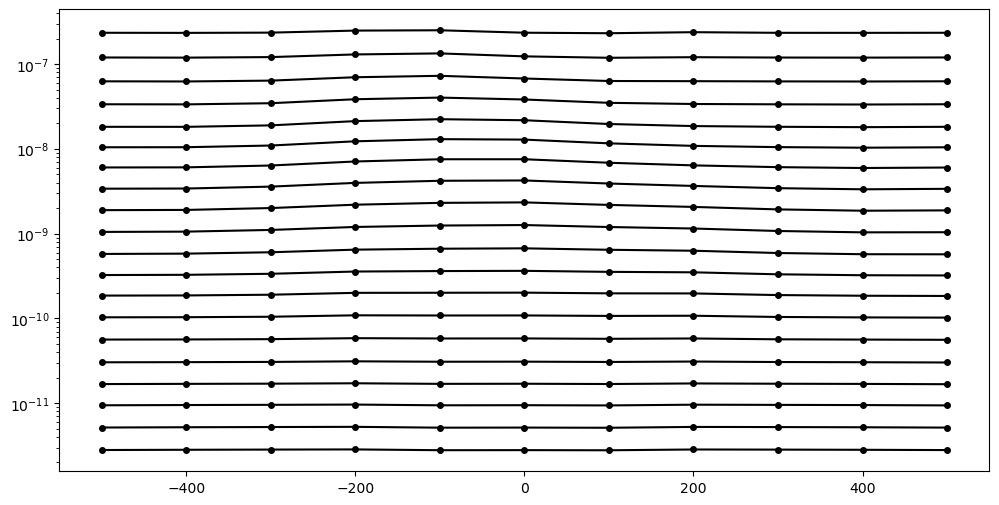

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.semilogy(rx_x, -dobs_reshaped[4, :, :], "-ok", ms=4);

In [46]:
relative_error = 0.05
noise_floor = 1e-13

In [49]:
data_invert = Data(
    survey, dobs=dobs,
    standard_deviation=np.abs(dobs)*relative_error + noise_floor
)

In [50]:
dmis = data_misfit.L2DataMisfit(simulation=sim, data=data_invert)
reg = regularization.WeightedLeastSquares(
    global_mesh,
    active_cells=active_cells_map.active_cells,
)

In [51]:
opt = optimization.InexactGaussNewton(maxIter=20, maxIterCG=50)
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)


/home/lheagy/git/simpeg/simpeg/simpeg/optimization.py:1061: FutureWarning: InexactCG.maxIterCG has been deprecated, please use InexactCG.cg_maxiter. It will be removed in version 0.26.0 of SimPEG.
  self.maxIterCG = val


In [52]:
# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10, n_pw_iter=1)
cool_beta = directives.BetaSchedule(coolingFactor=2, coolingRate=3)
# Options for outputting recovered models and predicted data for each beta.
save_iteration = directives.SaveOutputDictEveryIteration(
    saveOnDisk=True,
)
target_misfit = directives.TargetMisfit()

/home/lheagy/git/simpeg/simpeg/simpeg/directives/_directives.py:2113: FutureWarning: SaveEveryIteration.saveOnDisk has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  self.saveOnDisk = save_on_disk
/home/lheagy/git/simpeg/simpeg/simpeg/directives/_directives.py:2114: FutureWarning: SaveEveryIteration.saveOnDisk has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  on_disk = self.saveOnDisk


In [53]:
# The directives are defined as a list.
directives_list = [
    starting_beta,
    cool_beta,
    save_iteration,
    target_misfit,
]

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

In [ ]:
m0 = np.log(sigma_background)*np.ones(np.sum(active_cells_map.active_cells))